In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


In [6]:
import numpy as np
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from pathlib import Path
from tqdm import tqdm
import pyreadr
import matplotlib.pyplot as plt

# ================================================================
# 0. CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD DATA
# ================================================================

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

keep_idx = np.setdiff1d(np.arange(snow.shape[0]), no_nbs)

coords = snow.iloc[keep_idx, :2].to_numpy()
y_obs = snow.iloc[keep_idx, 2:].to_numpy()   # (S, T)

S, T = y_obs.shape
print(f"S = {S}, T = {T}")

# ================================================================
# 2. BUILD RAW ADJACENCY MATRIX W
# ================================================================

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

Dmat = squareform(pdist(xy))
W = (Dmat <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

# upper-triangle edges (count each neighbor pair once)
ii, jj = np.triu(W.toarray(), k=1).nonzero()

# ================================================================
# 3. NEIGHBOR COUNT STATISTICS
# ================================================================

def count_11_00(y, ii, jj):
    """
    y: (S,) binary vector
    returns: N11, N00
    """
    y_i = y[ii]
    y_j = y[jj]
    N11 = np.sum((y_i == 1) & (y_j == 1))
    N00 = np.sum((y_i == 0) & (y_j == 0))
    return N11, N00

# ================================================================
# 4. OBSERVED STATISTICS
# ================================================================

N11_obs = np.zeros(T)
N00_obs = np.zeros(T)

for t in range(T):
    N11_obs[t], N00_obs[t] = count_11_00(y_obs[:, t], ii, jj)

# ================================================================
# 5. LOAD POSTERIOR SAMPLES
# ================================================================

bym01 = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"]

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

M = bym01.shape[1]
print(f"Posterior draws M = {M}")

# ================================================================
# 6. TIME COVARIATES
# ================================================================

t_raw = np.arange(1, T + 1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw / period), np.cos(2*np.pi*t_raw / period),
    np.sin(2*np.pi*t_raw / period), np.sin(2*np.pi*t_raw / period),
    t_trend, t_trend
])

cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw / period),
    np.sin(2*np.pi*t_raw / period),
    t_trend
])

K_bym = cov_bym.shape[1]
K_iid = cov_iid.shape[1]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ================================================================
# 7. PPC SIMULATION
# ================================================================

N11_bym = np.zeros((T, M))
N00_bym = np.zeros((T, M))

N11_iid = np.zeros((T, M))
N00_iid = np.zeros((T, M))

for m in tqdm(range(M), desc="PPC neighbor counts"):

    # ---------- BYM ----------
    eta01 = np.zeros((S, T))
    eta10 = np.zeros((S, T))
    for t in range(T):
        for k in range(K_bym):
            eta01[:, t] += cov_bym[t, k] * bym01[k*S:(k+1)*S, m]
            eta10[:, t] += cov_bym[t, k] * bym10[k*S:(k+1)*S, m]

    p01 = sigmoid(eta01)
    p10 = sigmoid(eta10)

    p_state = np.zeros((S, T))
    p_state[:, 0] = y_obs[:, 0]

    for t in range(1, T):
        p_state[:, t] = (
            p_state[:, t-1] * (1 - p10[:, t]) +
            (1 - p_state[:, t-1]) * p01[:, t]
        )

    y_rep = np.random.binomial(1, p_state)

    for t in range(T):
        N11_bym[t, m], N00_bym[t, m] = count_11_00(y_rep[:, t], ii, jj)

    # ---------- IID ----------
    eta01 = np.zeros((S, T))
    eta10 = np.zeros((S, T))
    for t in range(T):
        for k in range(K_iid):
            eta01[:, t] += cov_iid[t, k] * iid01[k*S:(k+1)*S, m]
            eta10[:, t] += cov_iid[t, k] * iid10[k*S:(k+1)*S, m]

    p01 = sigmoid(eta01)
    p10 = sigmoid(eta10)

    p_state = np.zeros((S, T))
    p_state[:, 0] = y_obs[:, 0]

    for t in range(1, T):
        p_state[:, t] = (
            p_state[:, t-1] * (1 - p10[:, t]) +
            (1 - p_state[:, t-1]) * p01[:, t]
        )

    y_rep = np.random.binomial(1, p_state)

    for t in range(T):
        N11_iid[t, m], N00_iid[t, m] = count_11_00(y_rep[:, t], ii, jj)

# ================================================================
# 8. PPC P-VALUES
# ================================================================

pval_N11_bym = np.mean(N11_bym >= N11_obs[:, None], axis=1)
pval_N00_bym = np.mean(N00_bym >= N00_obs[:, None], axis=1)

pval_N11_iid = np.mean(N11_iid >= N11_obs[:, None], axis=1)
pval_N00_iid = np.mean(N00_iid >= N00_obs[:, None], axis=1)

# ================================================================
# 9. SAVE
# ================================================================

np.savez_compressed(
    BASE_DIR / "ppc_neighbor_11_00_bym_iid.npz",
    N11_obs=N11_obs,
    N00_obs=N00_obs,
    pval_N11_bym=pval_N11_bym,
    pval_N00_bym=pval_N00_bym,
    pval_N11_iid=pval_N11_iid,
    pval_N00_iid=pval_N00_iid
)

print("Saved PPC neighbor count results.")


S = 1601, T = 2704
Posterior draws M = 1000


PPC neighbor counts: 100%|██████████| 1000/1000 [27:29<00:00,  1.65s/it]

Saved PPC neighbor count results.


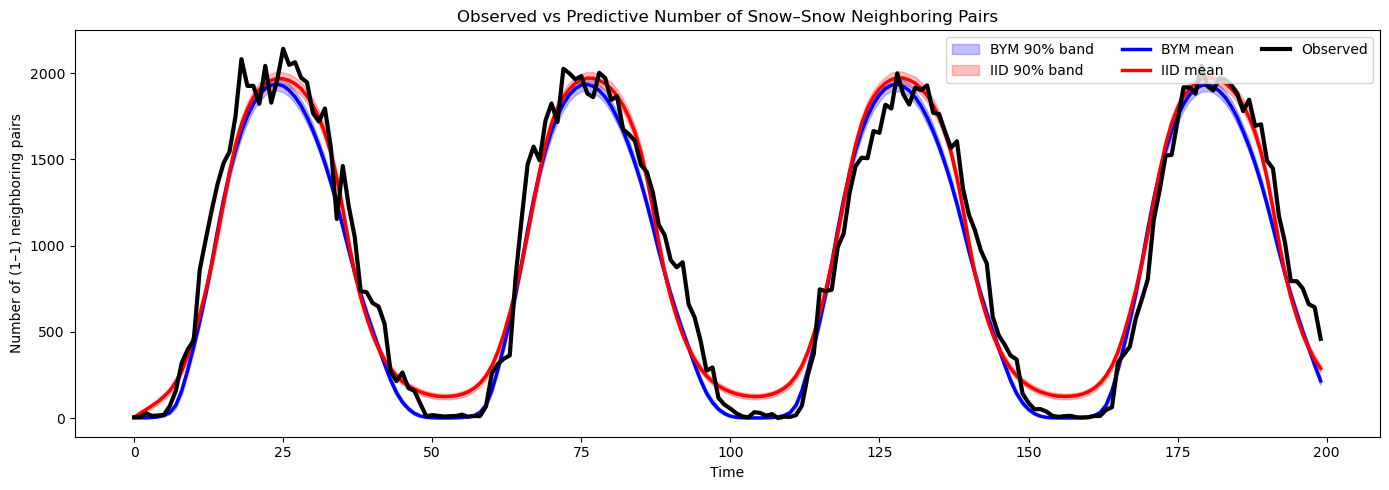

In [9]:
# ================================================================
# CLEAN TIME-SERIES PLOT: N11 COUNTS (t = 0–200)
# ================================================================

T_show = 200
t = np.arange(T_show)

# posterior summaries
N11_bym_mean = np.mean(N11_bym, axis=1)
N11_iid_mean = np.mean(N11_iid, axis=1)

N11_bym_lo = np.quantile(N11_bym, 0.05, axis=1)
N11_bym_hi = np.quantile(N11_bym, 0.95, axis=1)

N11_iid_lo = np.quantile(N11_iid, 0.05, axis=1)
N11_iid_hi = np.quantile(N11_iid, 0.95, axis=1)

plt.figure(figsize=(14,5))

# uncertainty bands
plt.fill_between(
    t,
    N11_bym_lo[:T_show],
    N11_bym_hi[:T_show],
    color="blue",
    alpha=0.25,
    label="BYM 90% band"
)

plt.fill_between(
    t,
    N11_iid_lo[:T_show],
    N11_iid_hi[:T_show],
    color="red",
    alpha=0.25,
    label="IID 90% band"
)

# posterior means
plt.plot(
    t,
    N11_bym_mean[:T_show],
    color="blue",
    lw=2.5,
    label="BYM mean"
)

plt.plot(
    t,
    N11_iid_mean[:T_show],
    color="red",
    lw=2.5,
    label="IID mean"
)

# observed
plt.plot(
    t,
    N11_obs[:T_show],
    color="black",
    lw=3,
    label="Observed"
)

plt.xlabel("Time")
plt.ylabel("Number of (1–1) neighboring pairs")
plt.title("Observed vs Predictive Number of Snow–Snow Neighboring Pairs")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


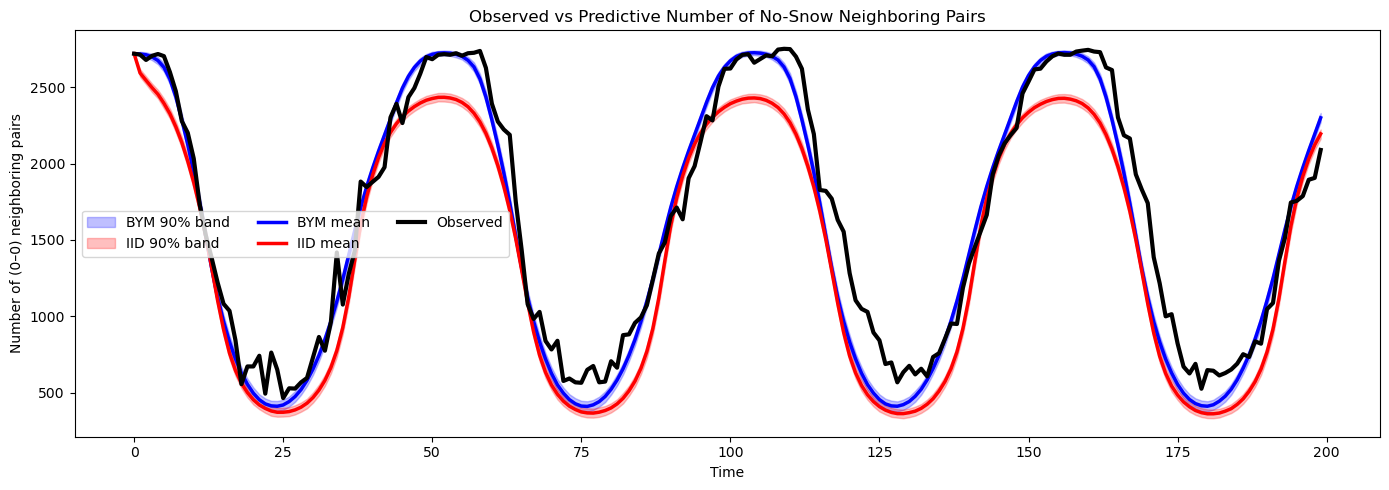

In [10]:
# ================================================================
# CLEAN TIME-SERIES PLOT: N00 COUNTS (t = 0–200)
# ================================================================

T_show = 200
t = np.arange(T_show)

# posterior summaries
N00_bym_mean = np.mean(N00_bym, axis=1)
N00_iid_mean = np.mean(N00_iid, axis=1)

N00_bym_lo = np.quantile(N00_bym, 0.05, axis=1)
N00_bym_hi = np.quantile(N00_bym, 0.95, axis=1)

N00_iid_lo = np.quantile(N00_iid, 0.05, axis=1)
N00_iid_hi = np.quantile(N00_iid, 0.95, axis=1)

plt.figure(figsize=(14,5))

# uncertainty bands
plt.fill_between(
    t,
    N00_bym_lo[:T_show],
    N00_bym_hi[:T_show],
    color="blue",
    alpha=0.25,
    label="BYM 90% band"
)

plt.fill_between(
    t,
    N00_iid_lo[:T_show],
    N00_iid_hi[:T_show],
    color="red",
    alpha=0.25,
    label="IID 90% band"
)

# posterior means
plt.plot(
    t,
    N00_bym_mean[:T_show],
    color="blue",
    lw=2.5,
    label="BYM mean"
)

plt.plot(
    t,
    N00_iid_mean[:T_show],
    color="red",
    lw=2.5,
    label="IID mean"
)

# observed
plt.plot(
    t,
    N00_obs[:T_show],
    color="black",
    lw=3,
    label="Observed"
)

plt.xlabel("Time")
plt.ylabel("Number of (0–0) neighboring pairs")
plt.title("Observed vs Predictive Number of No-Snow Neighboring Pairs")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


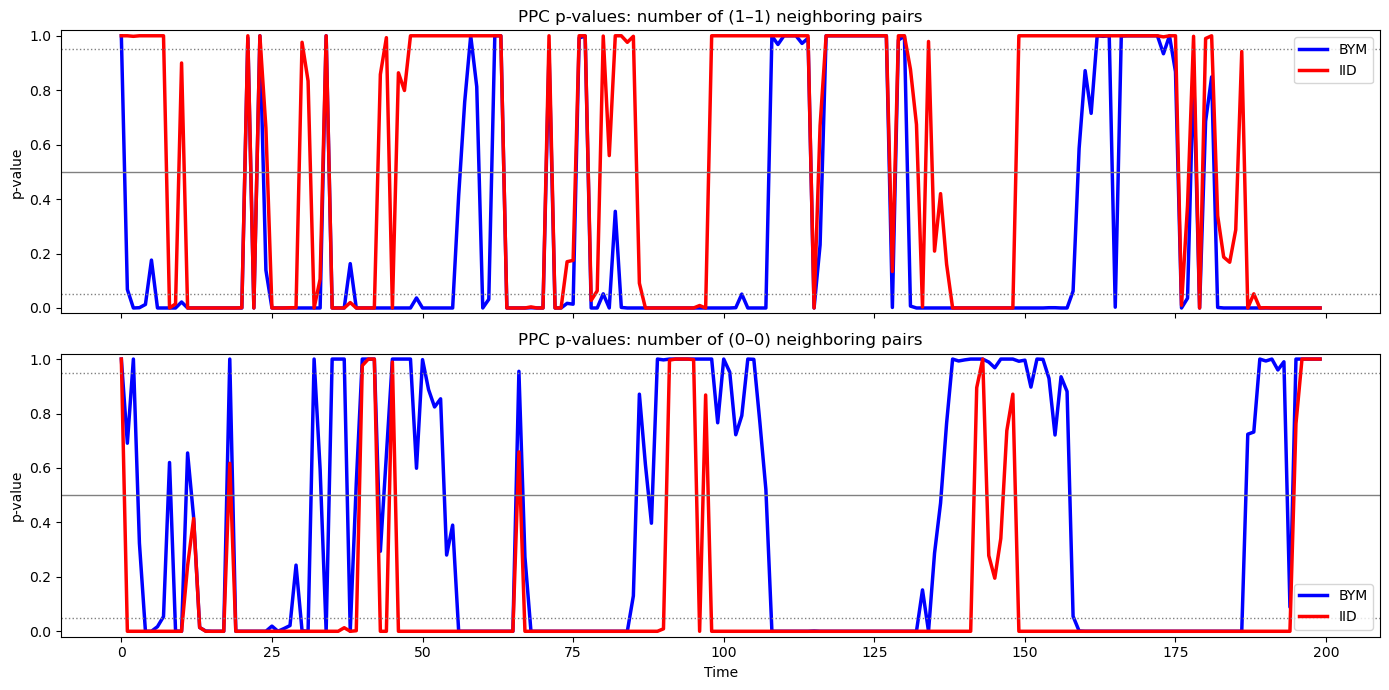

In [11]:
# ================================================================
# PPC P-VALUE TIME SERIES: N11 and N00 (t = 0–200)
# ================================================================

T_show = 200
t = np.arange(T_show)

fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)

# ===================== N11 =====================
axes[0].plot(
    t, pval_N11_bym[:T_show],
    color="blue", lw=2.5, label="BYM"
)
axes[0].plot(
    t, pval_N11_iid[:T_show],
    color="red", lw=2.5, label="IID"
)

axes[0].axhline(0.5, color="gray", lw=1)
axes[0].axhline(0.05, color="gray", lw=1, linestyle=":")
axes[0].axhline(0.95, color="gray", lw=1, linestyle=":")

axes[0].set_ylabel("p-value")
axes[0].set_title("PPC p-values: number of (1–1) neighboring pairs")
axes[0].set_ylim(-0.02, 1.02)
axes[0].legend()

# ===================== N00 =====================
axes[1].plot(
    t, pval_N00_bym[:T_show],
    color="blue", lw=2.5, label="BYM"
)
axes[1].plot(
    t, pval_N00_iid[:T_show],
    color="red", lw=2.5, label="IID"
)

axes[1].axhline(0.5, color="gray", lw=1)
axes[1].axhline(0.05, color="gray", lw=1, linestyle=":")
axes[1].axhline(0.95, color="gray", lw=1, linestyle=":")

axes[1].set_ylabel("p-value")
axes[1].set_title("PPC p-values: number of (0–0) neighboring pairs")
axes[1].set_xlabel("Time")
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()
